# Assignment: Pandas Fundamentals with Earthquake Data

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

### 1) Use Pandas’ read_csv function directly on this URL to open it as a DataFrame

In [20]:
url = 'http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv'
df = pd.read_csv(url)
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120108 entries, 0 to 120107
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       120108 non-null  object 
 1   latitude   120108 non-null  float64
 2   longitude  120108 non-null  float64
 3   depth      120107 non-null  float64
 4   mag        120065 non-null  float64
 5   magType    120065 non-null  object 
 6   nst        59688 non-null   float64
 7   gap        94935 non-null   float64
 8   dmin       85682 non-null   float64
 9   rms        119716 non-null  float64
 10  net        120108 non-null  object 
 11  id         120108 non-null  object 
 12  updated    120108 non-null  object 
 13  place      120108 non-null  object 
 14  type       120108 non-null  object 
dtypes: float64(8), object(7)
memory usage: 13.7+ MB


### 2) Re-read the data in such a way that all date columns are identified as dates and the earthquake ID is used as the index

In [22]:
df = pd.read_csv(url, parse_dates=['time', 'updated'], index_col='id')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05 19:34:41.515000+00:00,"26km S of Redoubt Volcano, Alaska",earthquake
nn00436847,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01 01:35:09+00:00,"32km S of Alamo, Nevada",earthquake
ak11151142,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01 00:03:53.010000+00:00,"12km NNW of North Nenana, Alaska",earthquake
ak11151135,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31 23:41:25.007000+00:00,"22km S of Cantwell, Alaska",earthquake
ci37171541,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01 00:13:20.107000+00:00,"10km WNW of Progreso, Mexico",earthquake


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120108 entries, ak11155107 to ak11453389
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   time       120108 non-null  datetime64[ns]     
 1   latitude   120108 non-null  float64            
 2   longitude  120108 non-null  float64            
 3   depth      120107 non-null  float64            
 4   mag        120065 non-null  float64            
 5   magType    120065 non-null  object             
 6   nst        59688 non-null   float64            
 7   gap        94935 non-null   float64            
 8   dmin       85682 non-null   float64            
 9   rms        119716 non-null  float64            
 10  net        120108 non-null  object             
 11  updated    120108 non-null  datetime64[ns, UTC]
 12  place      120108 non-null  object             
 13  type       120108 non-null  object             
dtypes: datetime64[ns, UTC](1), d

### 3) Use `describe` to get the basic statistics of all the columns

In [4]:
df.describe()

,time,latitude,longitude,depth,mag,nst,gap,dmin,rms
count,120108,120108.000000,120108.000000,120107.000000,120065.000000,59688.000000,94935.000000,85682.000000,119716.000000
mean,2014-07-05 09:10:37.116720128,38.399579,-99.961402,28.375029,1.793958,17.878284,124.048978,0.893198,0.358174
min,2014-01-01 00:01:16.610000,-73.462000,-179.998900,-9.900000,-0.970000,0.000000,9.000000,0.000000,0.000000
25%,2014-04-08 03:43:10.768999936,34.228917,-147.742025,4.100000,0.820000,8.000000,74.000000,0.020760,0.070000
50%,2014-07-07 10:44:06.035000064,38.805300,-120.832000,9.200000,1.400000,14.000000,107.000000,0.073670,0.200000
75%,2014-09-30 23:36:40.595000064,53.889500,-116.068100,22.880000,2.400000,22.000000,155.000000,0.447000,0.590000
max,2014-12-31 23:54:33.900000,86.651400,179.998000,697.360000,8.200000,365.000000,356.400000,64.498000,8.460000
std,NaN,21.938258,82.996858,62.215416,1.343466,14.911369,68.518595,2.903966,0.364046


In [25]:
print("Highest:", df['mag'].max())

Highest: 8.2


In [26]:
print("Lowest:", df["mag"].min())

Lowest: -0.97


### 4) Use `nlargest` to get the top 20 earthquakes by magnitude

In [29]:
top20 = df.nlargest(20, 'mag')
(top20[['mag', 'place']])

,mag,place
id,,
usc000nzvd,8.2,"94km NW of Iquique, Chile"
usc000rki5,7.9,"19km SE of Little Sitkin Island, Alaska"
usc000p27i,7.7,"53km SW of Iquique, Chile"
usc000phx5,7.6,"93km SSE of Kirakira, Solomon Islands"
usb000pr89,7.5,"70km SW of Panguna, Papua New Guinea"
usc000piqj,7.4,"112km S of Kirakira, Solomon Islands"
usb000slwn,7.3,"74km S of Intipuca, El Salvador"
usb000pq41,7.2,"33km ESE of Petatlan, Mexico"
usc000pft9,7.1,"56km WSW of Panguna, Papua New Guinea"


### 5) Extract the state or country using Pandas text data functions

In [30]:
df['country'] = df['place'].str.split(',').str[-1]
df[['place','country']].head()

,place,country
id,,
ak11155107,"26km S of Redoubt Volcano, Alaska",Alaska
nn00436847,"32km S of Alamo, Nevada",Nevada
ak11151142,"12km NNW of North Nenana, Alaska",Alaska
ak11151135,"22km S of Cantwell, Alaska",Alaska
ci37171541,"10km WNW of Progreso, Mexico",Mexico


### 6) Display each unique value from the new column

In [7]:
df['country'].unique()

array(['Alaska', 'Nevada', 'Mexico', 'California', 'Papua New Guinea',
       'New Zealand', 'Missouri', 'South of the Fiji Islands', 'Montana',
       'British Virgin Islands', 'Washington', 'Oregon', 'Canada', 'Fiji',
       'Wyoming', 'Antarctica', 'Chile', 'Utah', 'Indonesia',
       'Solomon Islands', 'Micronesia', 'Oklahoma', 'Hawaii', 'Russia',
       'Arizona', 'Philippines', 'Bolivia', 'Greece', 'Japan',
       'Puerto Rico', 'Iran', 'Tonga', 'Wallis and Futuna', 'Colorado',
       'Guam', 'CA', 'Carlsberg Ridge', 'Idaho', 'Pakistan',
       'Off the west coast of northern Sumatra', 'Burma', 'China', 'Peru',
       'Off the east coast of the North Island of New Zealand',
       'Costa Rica', 'Reykjanes Ridge', 'East Timor',
       'Central East Pacific Rise', 'Mid-Indian Ridge', 'Japan region',
       'Northern Mariana Islands', 'El Salvador', 'Samoa',
       'Northern Mid-Atlantic Ridge', 'Taiwan', 'Arkansas',
       'South Sandwich Islands', 'Colombia', 'Dominican Republic',

### 7) Create a filtered dataset that only has earthquakes of magnitude 4 or larger

In [8]:
df_filtered = df[df['mag'] >= 4]
df_filtered.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,country
id,,,,,,,,,,,,,,,
usc000mqlp,2014-01-31 23:08:03.660,-4.9758,153.9466,110.18,4.2,mb,NaN,98.0,1.940,0.61,us,2014-04-08 01:43:19+00:00,"115km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea
usc000mqln,2014-01-31 22:54:32.970,-28.1775,-177.9058,95.84,4.3,mb,NaN,104.0,1.063,1.14,us,2014-04-08 01:43:19+00:00,"120km N of Raoul Island, New Zealand",earthquake,New Zealand
usc000mqls,2014-01-31 22:49:49.740,-23.1192,179.1174,528.34,4.4,mb,NaN,80.0,5.439,0.95,us,2014-04-08 01:43:19+00:00,South of the Fiji Islands,earthquake,South of the Fiji Islands
usc000mf1x,2014-01-31 22:19:44.330,51.1569,-178.0910,37.50,4.2,mb,NaN,NaN,NaN,0.83,us,2014-04-08 01:43:19+00:00,"72km E of Amatignak Island, Alaska",earthquake,Alaska
usc000mqlm,2014-01-31 21:56:44.320,-4.8800,153.8434,112.66,4.3,mb,NaN,199.0,1.808,0.79,us,2014-04-08 01:43:19+00:00,"100km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea


### 8) Using the filtered dataset (magnitude > 4), count the number of earthquakes in each country/state. Make a bar chart of this number for the top 5 locations with the most earthquakes

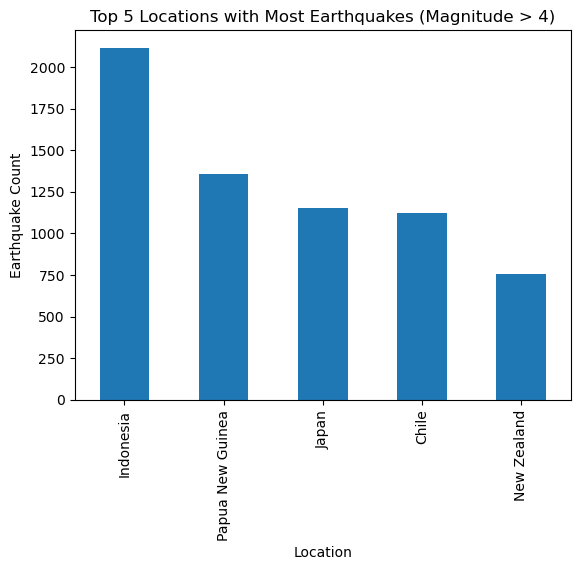

In [32]:
top5 = df_filtered['country'].value_counts().head(5)

top5.plot(kind='bar')
plt.xlabel('Location')
plt.ylabel('Earthquake Count')
plt.title('Top 5 Locations with Most Earthquakes (Magnitude > 4)')
plt.show()

### 9) Make a histogram the distribution of the Earthquake magnitudes

/tmp/ipykernel_445908/854000317.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0].set_ylim((0, 1e4))
/tmp/ipykernel_445908/854000317.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[1].set_ylim((0, 1e4))


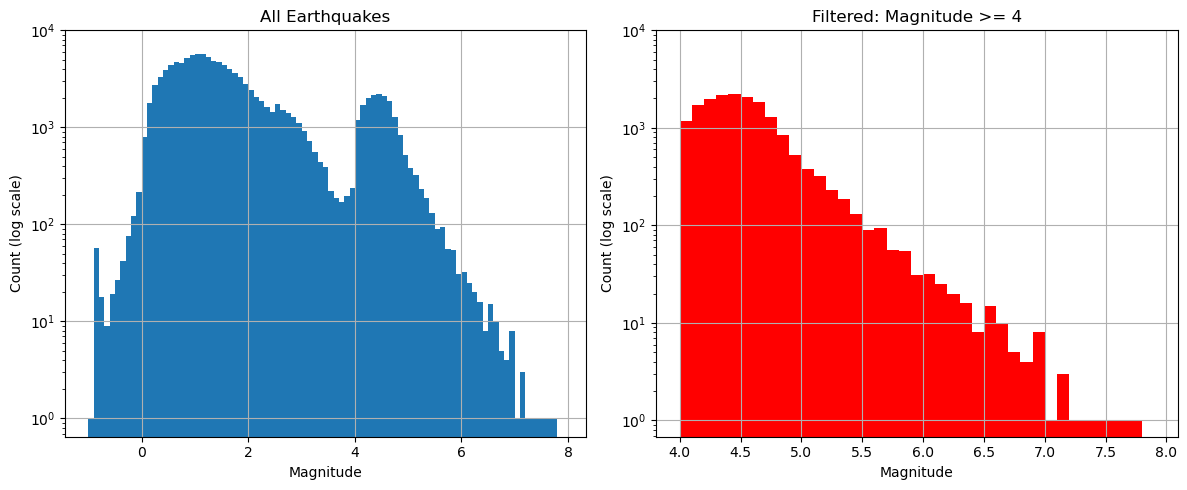

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.hist('mag', bins=np.arange(-1, 8, 0.1), log=True, ax=axes[0])
axes[0].set_title('All Earthquakes')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_ylim((0, 1e4))

df_filtered.hist('mag', bins=np.arange(4, 8, 0.1), log=True, color='red', ax=axes[1])
axes[1].set_title('Filtered: Magnitude >= 4')
axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_ylim((0, 1e4))

plt.tight_layout()
plt.show()

All Earthquakes: The unfiltered histogram shows a bimodal distribution with two visible peaks, one around magnitude 1 and another around magnitude 4.5. The majority of earthquakes fall between magnitudes 0 and 3. Very few earthquakes occur at negative magnitudes or above magnitude 6, and the count drops off sharply at higher magnitudes.

Filtered (Magnitude >= 4): After filtering, the distribution becomes unimodal with a single peak near magnitude 4.5. The distribution is right-skewed, meaning most earthquakes cluster at the lower end of the filtered range and the frequency decreases steadily as magnitude increases toward 7.5. This confirms that large earthquakes are relatively rare even among the stronger events.

### 10) Visualize the locations of earthquakes by making a scatterplot of their latitude and longitude

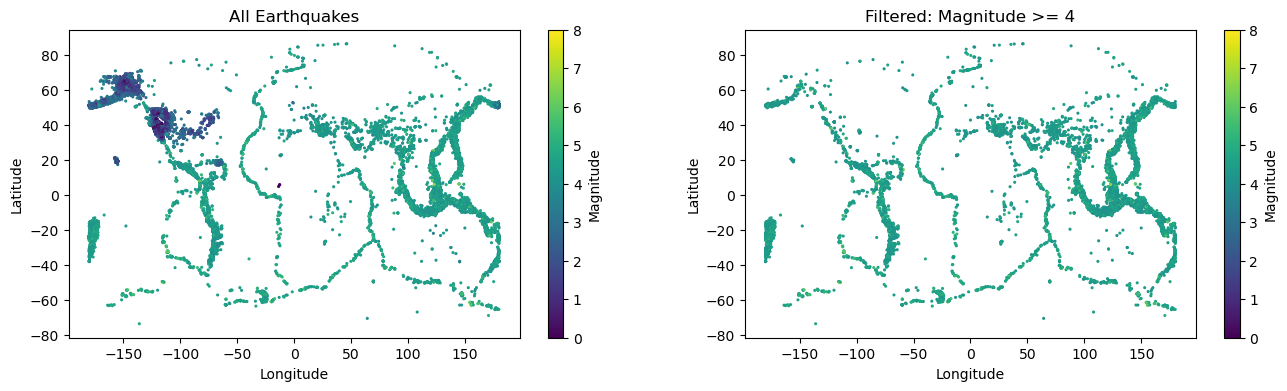

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

scatter1 = axes[0].scatter(
    df['longitude'], df['latitude'],
    c=df['mag'], s=1.5,
    vmin=0, vmax=8
)
axes[0].set_title('All Earthquakes')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(scatter1, ax=axes[0], label='Magnitude')

scatter2 = axes[1].scatter(
    df_filtered['longitude'], df_filtered['latitude'],
    c=df_filtered['mag'], s=1.5,
    vmin=0, vmax=8
)
axes[1].set_title('Filtered: Magnitude >= 4')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(scatter2, ax=axes[1], label='Magnitude')

plt.show()

The two scatterplots reveal both similarities and differences between the filtered and unfiltered datasets. Both plots clearly show that earthquakes are concentrated along tectonic plate boundaries, particularly the Ring of Fire around the Pacific Ocean.

The most notable difference is in North America (-170° to -50° longitude, 18° to 75° latitude). The unfiltered plot shows a dense cluster of low-magnitude earthquakes (shown in dark blue/purple) across the continental US, Alaska, and Hawaii that largely disappear in the filtered dataset. This is likely because the USGS, being a US government agency, records smaller earthquakes in the US more comprehensively than in other parts of the world.

In the unfiltered dataset, most earthquakes fall between magnitude 3-6, appearing as blue-green and teal points. In the filtered dataset, the range shifts to roughly magnitude 4-6, which makes sense given the cutoff. The colorbar scale (vmin=0, vmax=8) is the same for both plots, making direct comparison straightforward.

A few scattered low-magnitude points visible near central Africa and central Europe in the unfiltered plot are absent in the filtered version. Overall, the filtered dataset gives a cleaner picture of global seismic activity along plate boundaries, without the regional bias introduced by the dense US monitoring network.